In [1]:
# importing the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# loading the main 2020 covid dataset to investigate the pandemic's impact
df_covid = pd.read_csv('Unemployment_Rate_upto_11_2020.csv')

In [3]:
# checking the size of our dataset (rows, columns)
print("Dataset Shape: ", df_covid.shape, "\n", sep="")

Dataset Shape: (267, 9)



In [4]:
# checking the basic math statistics for our numeric columns
print("Statistical Summary:")
display(df_covid.describe())

Statistical Summary:


,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),longitude,latitude
count,267.000000,2.670000e+02,267.000000,267.000000,267.000000
mean,12.236929,1.396211e+07,41.681573,22.826048,80.532425
std,10.803283,1.336632e+07,7.845419,6.270731,5.831738
min,0.500000,1.175420e+05,16.770000,10.850500,71.192400
25%,4.845000,2.838930e+06,37.265000,18.112400,76.085600
50%,9.650000,9.732417e+06,40.390000,23.610200,79.019300
75%,16.755000,2.187869e+07,44.055000,27.278400,85.279900
max,75.850000,5.943376e+07,69.690000,33.778200,92.937600


In [5]:
# checking the raw data first to see what needs to be cleaned
print("\nMissing values before cleaning:")
print(df_covid.isnull().sum())


Missing values before cleaning:
Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64


In [6]:
df_covid.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [7]:
# fixing the invisible spaces in column names
df_covid.columns = df_covid.columns.str.strip()

# dropping any empty rows to keep the math and graphs clean
df_covid.dropna(inplace=True)

In [8]:
# making sure that python knows this is an actual date and the day comes first
df_covid['Date'] = pd.to_datetime(df_covid['Date'], dayfirst=True)

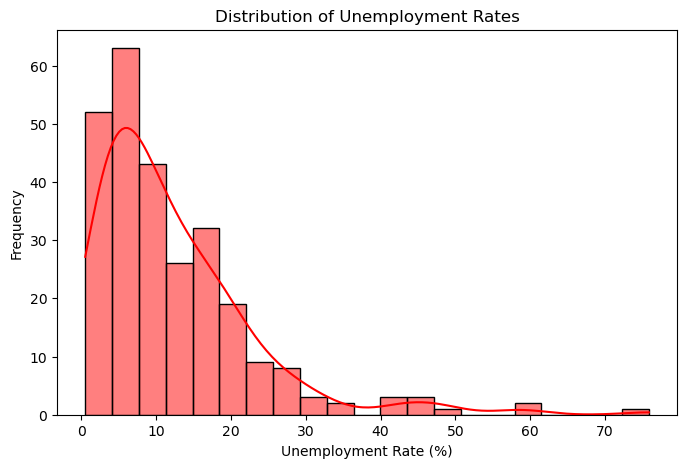

In [9]:
# Univariate Analysis: how the unemployment rates are distributed overall
plt.figure(figsize=(8, 5))
sns.histplot(df_covid['Estimated Unemployment Rate (%)'], kde=True, color='red')
plt.title('Distribution of Unemployment Rates')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Frequency')
plt.show()

Key Finding: The Normal vs. The Panic

This red graph shows how often different unemployment rates happen. Most of the time, the rate is low and safe, staying under 10%. But that long tail stretching to the right shows there were a few months where the rate went dangerously high, past 30%. Those crazy high numbers show exactly the moment the pandemic lockdowns hit.

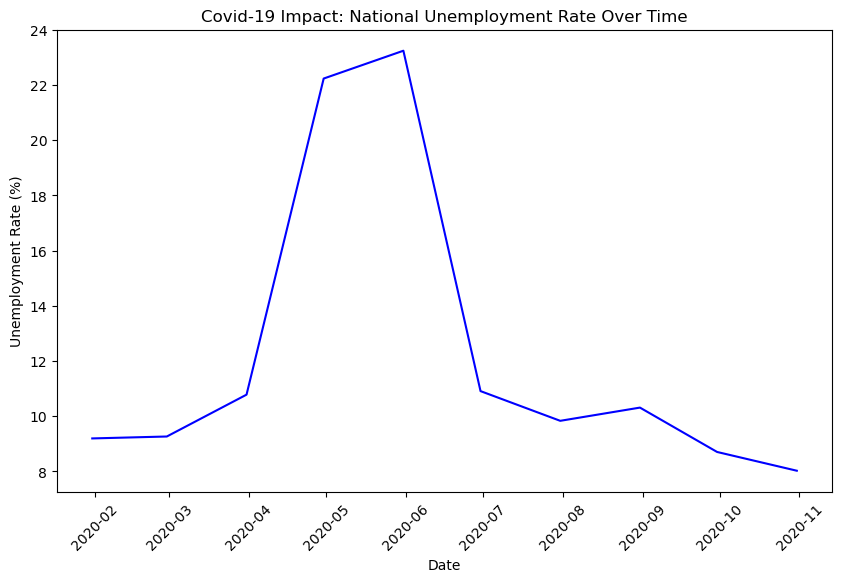

In [10]:
# Bivariate Analysis: the date and the unemployment rate to clearly see the covid timeline spike
plt.figure(figsize=(10, 6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df_covid, color='blue', errorbar=None)
plt.title('Covid-19 Impact: National Unemployment Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.show()

Key Finding: The Timeline of Job Losses

This blue line tells the clear story of 2020. Before April, the unemployment rate was normal, around 8% or 9%. But in April and May, the line shoots straight up past 23%, which matches exactly when the country went into strict lockdown. As the year went on, the line slowly went back down, showing the economy slowly healing.

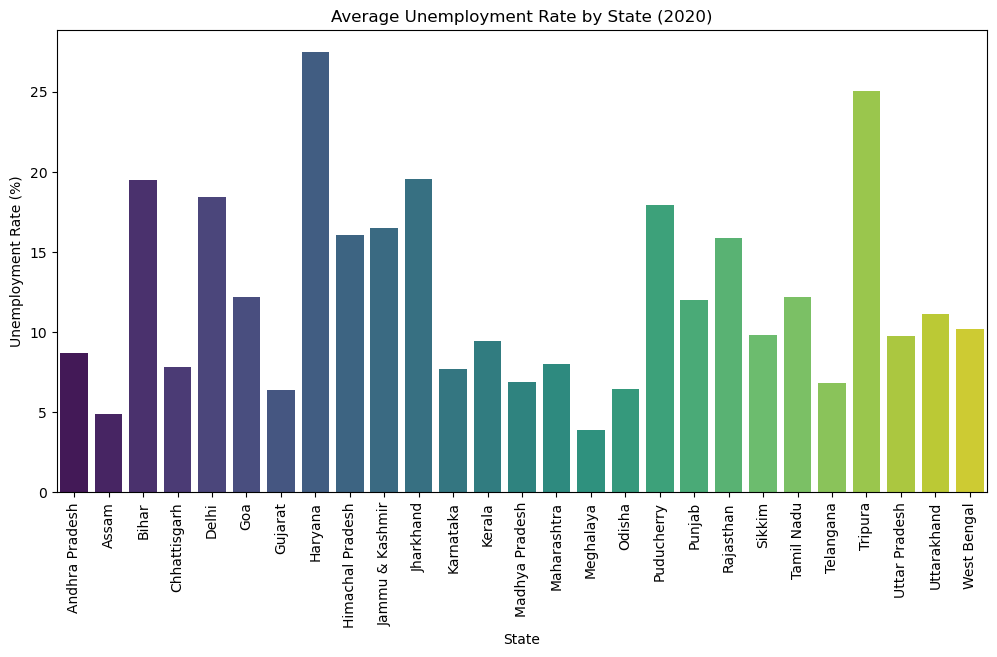

In [11]:
# Trivariate Analysis: states, unemployment rate, and color-coding by the state itself
# using hue and legend = False to silence the seaborn warning and keep it clean
plt.figure(figsize=(12, 6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', hue='Region', data=df_covid, legend=False, palette='viridis', errorbar=None)
plt.title('Average Unemployment Rate by State (2020)')
plt.xlabel('State')
plt.ylabel('Unemployment Rate (%)')
plt.xticks(rotation=90)
plt.show()

Key Finding: How Different States Suffered

This chart looks at the states, and it shows that the pandemic wasn't the same everywhere. Some states like Haryana, Tripura, and Jharkhand had a really hard time, with huge unemployment rates over 20%. But other states like Assam and Meghalaya stayed pretty normal. This tells us that the lockdowns hurt some local areas much more than others.

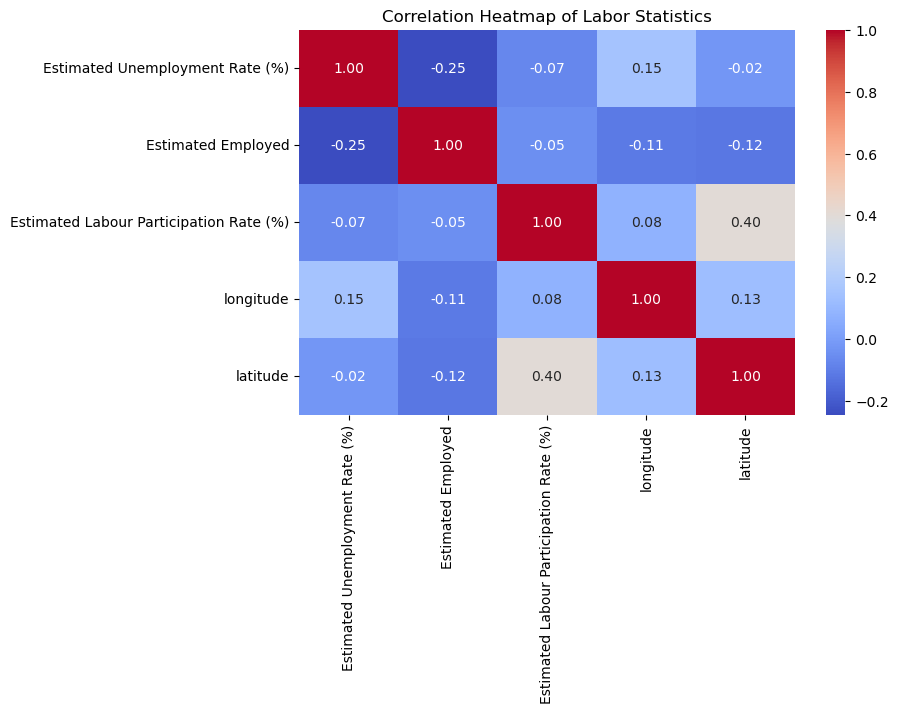

In [12]:
# Multivariate Analys: making a heatmap to see how employment, unemployment, and labor participation correlate
plt.figure(figsize=(8, 5))
# only selecting the number columns so the heatmap math doesn't break
numeric_cols = df_covid.select_dtypes(include=['float64', 'int64'])
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Labor Statistics')
plt.show()

Key Finding: The Proof of Job Loss

This colored map shows how different numbers connect to each other. The dark blue square (-0.25) is the most important part. It shows a simple rule: when the total number of people with jobs drops, the unemployment percentage naturally goes up. It proves that the big spike we saw wasn't just a mistake in the data; real people were losing their jobs.

In [13]:
# using numpy to find the absolute peak and average for my conclusion
mean_rate = np.mean(df_covid['Estimated Unemployment Rate (%)'])
max_rate = np.max(df_covid['Estimated Unemployment Rate (%)'])

# engineering a new column using numpy logic to label high/low severity zones
df_covid['Severity'] = np.where(df_covid['Estimated Unemployment Rate (%)'] > mean_rate, 'High', 'Low')

# counting how many 'High' and 'Low' records we have
print("Breakdown of Severity Zones:")
print(df_covid['Severity'].value_counts())
print("\n")

# taking a quick peek at the table to prove the new column was added successfully
df_covid[['Region', 'Date', 'Estimated Unemployment Rate (%)', 'Severity']].head()

Breakdown of Severity Zones:
Severity
Low     168
High     99
Name: count, dtype: int64




,Region,Date,Estimated Unemployment Rate (%),Severity
0,Andhra Pradesh,2020-01-31,5.48,Low
1,Andhra Pradesh,2020-02-29,5.83,Low
2,Andhra Pradesh,2020-03-31,5.79,Low
3,Andhra Pradesh,2020-04-30,20.51,High
4,Andhra Pradesh,2020-05-31,17.43,High


In [14]:
# loading the older historical dataset to find the normal pre-covid average
df_history = pd.read_csv('Unemployment in India.csv')

# cleaning it using the exact same logic as before
df_history.columns = df_history.columns.str.strip()
df_history.dropna(inplace=True)

# calculating the pre-covid national average
pre_covid_avg = np.mean(df_history['Estimated Unemployment Rate (%)'])

In [15]:
# mathematically proving exactly how much the rate jumped during covid
rate_jump = mean_rate - pre_covid_avg

# rounding the numbers to 2 decimal places using basic python math
pre_covid_rounded = round(pre_covid_avg, 2)
mean_rounded = round(mean_rate, 2)
max_rounded = round(max_rate, 2)
jump_rounded = round(rate_jump, 2)

# printing a formatted executive summary using the comma method
print("=====================================================")
print(" UNEMPLOYMENT ANALYSIS: EXECUTIVE SUMMARY")
print("=====================================================")
print("1. Pre-Pandemic National Average:  ", pre_covid_rounded, "%", sep="")
print("2. Overall 2020 National Average:  ", mean_rounded, "%", sep="")
print("3. Worst State-Level Peak Hit:     ", max_rounded, "%", sep="")
print("-----------------------------------------------------")
print("CONCLUSION: While the overall yearly average only shifted")
print("by ", jump_rounded, "%, the initial Covid-19 lockdown shock caused", sep="")
print("local unemployment rates to temporarily skyrocket to ", max_rounded, "%!", sep="")
print("=====================================================")

 UNEMPLOYMENT ANALYSIS: EXECUTIVE SUMMARY
1. Pre-Pandemic National Average:  11.79%
2. Overall 2020 National Average:  12.24%
3. Worst State-Level Peak Hit:     75.85%
-----------------------------------------------------
CONCLUSION: While the overall yearly average only shifted
by 0.45%, the initial Covid-19 lockdown shock caused
local unemployment rates to temporarily skyrocket to 75.85%!
